# GRU Model 

In [11]:
"""
Imports
"""

from abc import ABC, abstractmethod
import numpy as np
import pandas as pd
import pickle
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import yfinance as yf
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0
CUDA available: False


In [12]:
"""
Base Template for Forecasting Models
"""

class BaseForecastModel(ABC):

    def __init__(self, task_type: str, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters

    @abstractmethod
    def fit(self, X_train, y_train):
        """Train your model on the training data."""
        pass

    @abstractmethod
    def predict(self, X):
        """Make predictions on new data."""
        pass

    @abstractmethod
    def evaluate(self, X_test, y_test):
        """Evaluate model performance on test data."""
        pass

    @abstractmethod
    def save(self, filepath: str):
        """Save your trained model to a file."""
        pass

    @abstractmethod
    def load(self, filepath: str):
        """Load a previously saved model."""
        pass


print("Base class defined!")

Base class defined!


In [13]:
"""
GRU Module
"""

class GRUNet(nn.Module):
    """Raw PyTorch GRU network for time series forecasting."""

    def __init__(self, input_size, hidden_size=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_length, input_size)
        out, _ = self.gru(x)
        # Take last time step's hidden state
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze(-1)


print("GRUNet defined!")

GRUNet defined!


In [14]:
"""
GRU Forecast Model Implementation
"""

class GRUForecastModel(BaseForecastModel):
    """
    GRU model for commodity price forecasting.
    Inherits from BaseForecastModel and implements all required methods.
    """

    def __init__(self, task_type='regression', hidden_size=64, num_layers=2,
                 dropout=0.2, seq_length=12, epochs=100, lr=0.001, batch_size=32):
        super().__init__(
            task_type=task_type, hidden_size=hidden_size, num_layers=num_layers,
            dropout=dropout, seq_length=seq_length, epochs=epochs, lr=lr,
            batch_size=batch_size
        )
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout
        self.seq_length = seq_length
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size

        self.model = None
        self.feature_scaler = StandardScaler()
        self.target_scaler = StandardScaler()
        self.loss_history = []
        self.is_fitted = False
        self.input_size = None

    def _create_sequences(self, X, y=None):
        """Create sliding window sequences for the GRU.
        Returns (X_seq, y_seq) tensors of shape (samples, seq_length, features).
        """
        X_seqs, y_seqs = [], []
        for i in range(len(X) - self.seq_length):
            X_seqs.append(X[i : i + self.seq_length])
            if y is not None:
                y_seqs.append(y[i + self.seq_length])
        X_tensor = torch.FloatTensor(np.array(X_seqs))
        if y is not None:
            y_tensor = torch.FloatTensor(np.array(y_seqs))
            return X_tensor, y_tensor
        return X_tensor

    def fit(self, X_train, y_train):
        """Train the GRU model."""
        # Convert to numpy
        if isinstance(X_train, pd.DataFrame):
            X_train = X_train.values
        if isinstance(y_train, (pd.Series, pd.DataFrame)):
            y_train = y_train.values.ravel()

        # Scale
        X_scaled = self.feature_scaler.fit_transform(X_train)
        y_scaled = self.target_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()

        # Create sequences
        X_seq, y_seq = self._create_sequences(X_scaled, y_scaled)
        self.input_size = X_seq.shape[2]
        print(f"Training sequences: {X_seq.shape[0]} samples, "
              f"seq_length={self.seq_length}, features={self.input_size}")

        # Build model
        self.model = GRUNet(
            input_size=self.input_size,
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            dropout=self.dropout
        )

        # Training setup
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.MSELoss()
        dataset = TensorDataset(X_seq, y_seq)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        # Train
        self.model.train()
        self.loss_history = []
        for epoch in range(self.epochs):
            epoch_loss = 0.0
            for X_batch, y_batch in loader:
                optimizer.zero_grad()
                preds = self.model(X_batch)
                loss = criterion(preds, y_batch)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * len(X_batch)
            epoch_loss /= len(dataset)
            self.loss_history.append(epoch_loss)
            if (epoch + 1) % 20 == 0:
                print(f"  Epoch {epoch+1:3d}/{self.epochs}  Loss: {epoch_loss:.6f}")

        self.is_fitted = True
        print(f"Training complete! Final loss: {self.loss_history[-1]:.6f}")

    def predict(self, X):
        """Make predictions. X must have at least seq_length rows."""
        if not self.is_fitted:
            raise ValueError("Model not trained! Call fit() first.")

        if isinstance(X, pd.DataFrame):
            X = X.values

        X_scaled = self.feature_scaler.transform(X)
        X_seq = self._create_sequences(X_scaled)

        self.model.eval()
        with torch.no_grad():
            preds_scaled = self.model(X_seq).numpy()

        preds = self.target_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        return preds

    def evaluate(self, X_test, y_test):
        """Compute evaluation metrics."""
        predictions = self.predict(X_test)

        if isinstance(y_test, (pd.Series, pd.DataFrame)):
            y_test = y_test.values.ravel()

        # Align: predictions are shorter than y_test by seq_length
        y_aligned = y_test[self.seq_length:]

        mse = mean_squared_error(y_aligned, predictions)
        return {
            'mse': mse,
            'rmse': np.sqrt(mse),
            'mae': mean_absolute_error(y_aligned, predictions),
            'r2': r2_score(y_aligned, predictions)
        }

    def save(self, filepath: str):
        """Save the model."""
        with open(filepath, 'wb') as f:
            pickle.dump({
                'state_dict': self.model.state_dict(),
                'feature_scaler': self.feature_scaler,
                'target_scaler': self.target_scaler,
                'input_size': self.input_size,
                'hidden_size': self.hidden_size,
                'num_layers': self.num_layers,
                'dropout': self.dropout,
                'seq_length': self.seq_length,
                'loss_history': self.loss_history,
                'is_fitted': self.is_fitted,
            }, f)
        print(f"Model saved to {filepath}")

    def load(self, filepath: str):
        """Load a previously saved model."""
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
        self.feature_scaler = data['feature_scaler']
        self.target_scaler = data['target_scaler']
        self.input_size = data['input_size']
        self.hidden_size = data['hidden_size']
        self.num_layers = data['num_layers']
        self.dropout = data['dropout']
        self.seq_length = data['seq_length']
        self.loss_history = data['loss_history']
        self.is_fitted = data['is_fitted']
        # Reconstruct model and load weights
        self.model = GRUNet(
            input_size=self.input_size,
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            dropout=self.dropout
        )
        self.model.load_state_dict(data['state_dict'])
        self.model.eval()
        print(f"Model loaded from {filepath}")


print("GRUForecastModel defined!")

GRUForecastModel defined!


In [15]:
"""
Data Loading Functions
"""

BASE = "/Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models"

def load_fred_md(filepath):
    """Load a single FRED-MD vintage CSV."""
    print(f"Loading FRED-MD from: {filepath}")
    df = pd.read_csv(filepath)
    # First row is transformation codes — skip it
    df = df.iloc[1:].reset_index(drop=True)
    df['sasdate'] = pd.to_datetime(df['sasdate'], errors='coerce')
    df = df.dropna(subset=['sasdate']).set_index('sasdate')
    df.index.name = 'date'
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    # Normalise TWEX column name (older vintages use TWEXMMTH, newer use TWEXAFEGSMTHx)
    df.rename(columns={'TWEXMMTH': 'TWEXAFEGSMTHx'}, inplace=True)
    print(f"  → {df.shape[0]} rows, {df.shape[1]} columns")
    return df


def load_wheat_futures(ticker="ZW=F", start_date="1999-01-01"):
    """Load wheat futures from Yahoo Finance."""
    print(f"Downloading {ticker} from Yahoo Finance...")
    df = yf.download(ticker, start=start_date, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    print(f"  → {df.shape[0]} rows")
    return df


def merge_fred_wheat(fred_df, wheat_df):
    """Merge FRED-MD with monthly wheat prices."""
    wheat_monthly = wheat_df['Close'].resample('ME').last()
    wheat_monthly.name = 'Wheat_Price'
    fred_df.index = fred_df.index.to_period('M')
    wheat_monthly.index = wheat_monthly.index.to_period('M')
    merged = fred_df.join(wheat_monthly.to_frame(), how='inner')
    # Drop columns with >30% missing, forward-fill, drop remaining NaN
    missing_pct = merged.isnull().sum() / len(merged)
    merged = merged.loc[:, missing_pct <= 0.3]
    merged = merged.ffill().dropna()
    print(f"  → Merged: {merged.shape[0]} rows, {merged.shape[1]} columns")
    return merged


# Features specified in Agriculture - Lab Meetings.pdf
# Note: WPSFD49502 (PPI) and VIXCLSx (VIX) excluded — not present in training vintages
# TWEXAFEGSMTHx: older vintages use TWEXMMTH (renamed above in load_fred_md)
SELECTED_FEATURES = [
    'RPI',              # Real Personal Income
    'DPCERA3M086SBEA',  # Real Personal Consumption Expenditures
    'RETAILx',          # Retail and Food Services Sales
    'INDPRO',           # Industrial Production Index
    'NDMANEMP',         # Employment: Nondurable Goods
    'ACOGNO',           # New Orders: Consumer Goods
    'BUSINVx',          # Total Business Inventories
    'BUSLOANS',         # Commercial & Industrial Loans
    'S&P 500',          # S&P 500 Stock Index
    'FEDFUNDS',         # Federal Funds Rate
    'GS10',             # 10-Year Treasury Rate
    'TWEXAFEGSMTHx',    # Trade Weighted USD Index
    'CUSR0000SAC',      # CPI: Commodities
    'DNDGRG3M086SBEA',  # PCE: Nondurable Goods Deflator
    'CES0600000008',    # Avg Hourly Earnings: Goods-Producing
    'UMCSENTx',         # Consumer Sentiment Index
    'DTCTHFNM',         # Total Consumer Loans and Leases
    'Wheat_Price',      # Target
]


def select_features(df, features=SELECTED_FEATURES):
    """Select subset of variables and drop any missing."""
    available = [f for f in features if f in df.columns]
    missing = [f for f in features if f not in df.columns]
    if missing:
        print(f"  Warning — columns not found (skipped): {missing}")
    out = df[available].dropna()
    print(f"  → Selected {len(available)} variables, {len(out)} observations")
    return out


print("Data functions defined!")

Data functions defined!


In [ ]:
# ============================================================================
# Load Data — Train / Validation / Test
# ============================================================================

# Wheat futures (shared across all splits)
wheat_df = load_wheat_futures("ZW=F")

# --- TRAINING: 1999-08 to 2014-12 (document-specified range) ---
print("\n--- TRAINING DATA ---")
train_fred = load_fred_md(f"{BASE}/Historical FRED-MD Vintages Final/2014-12.csv")
train_merged = merge_fred_wheat(train_fred, wheat_df)
train_data = select_features(train_merged)
train_data = train_data.loc['1999-08':'2014-12']  # Restrict to document-specified range
print(f"  → After date filter (1999-08 – 201 4-12): {len(train_data)} observations")

# --- VALIDATION: 2015-01 to 2024-12 ---
print("\n--- VALIDATION DATA ---")
val_fred = load_fred_md(f"{BASE}/Historical-vintages-of-FRED-MD-2015-01-to-2024-12/FRED-MD_2024m12.csv")
val_merged = merge_fred_wheat(val_fred, wheat_df)
val_data = select_features(val_merged)
val_data = val_data[val_data.index > train_data.index[-1]]

# --- TEST: 2026-01-MD.csv ---
print("\n--- TEST DATA ---")
test_fred = load_fred_md(f"{BASE}/2026-01-MD.csv")
test_merged = merge_fred_wheat(test_fred, wheat_df)
test_data = select_features(test_merged)
test_data = test_data[test_data.index > val_data.index[-1]]

print(f"\nFinal split sizes — Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

# Separate features and target
target = 'Wheat_Price'
feature_cols = [c for c in train_data.columns if c != target]

X_train, y_train = train_data[feature_cols], train_data[target]
X_val, y_val = val_data[feature_cols], val_data[target]
X_test, y_test = test_data[feature_cols], test_data[target]

print(f"Features: {feature_cols}")
train_data.head()

  → 6419 rows

--- TRAINING DATA ---
Loading FRED-MD from: /Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models/Historical FRED-MD Vintages Final/2014-12.csv
  → 671 rows, 126 columns
  → Merged: 173 rows, 127 columns
  → Selected 18 variables, 173 observations
  → After date filter (1999-08 – 2014-12): 173 observations

--- VALIDATION DATA ---
Loading FRED-MD from: /Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models/Historical-vintages-of-FRED-MD-2015-01-to-2024-12/FRED-MD_2024m12.csv
  → 791 rows, 126 columns
  → Merged: 293 rows, 127 columns
  → Selected 18 variables, 293 observations

--- TEST DATA ---
Loading FRED-MD from: /Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models/2026-01-MD.csv
  → 804 rows, 126 columns
  → Merged: 306 rows, 127 col

,RPI,DPCERA3M086SBEA,RETAILx,INDPRO,NDMANEMP,ACOGNO,BUSINVx,BUSLOANS,S&P 500,FEDFUNDS,GS10,TWEXAFEGSMTHx,CUSR0000SAC,DNDGRG3M086SBEA,CES0600000008,UMCSENTx,DTCTHFNM,Wheat_Price
date,,,,,,,,,,,,,,,,,,
2000-07,10427.5,82.874,272638.0,92.6345,6393.0,125011.0,1175302.0,1068.6,1473.00,6.54,6.05,101.00,149.8,83.103,15.26,108.3,449083.0,246.0
2000-08,10477.3,83.313,272954.0,92.3191,6375.0,122095.0,1183156.0,1071.6,1485.46,6.50,5.83,102.55,149.2,82.677,15.32,107.3,456248.0,251.0
2000-09,10476.5,83.979,277523.0,92.6699,6356.0,126682.0,1183391.0,1072.9,1468.05,6.52,5.80,104.27,150.4,83.481,15.37,106.8,466633.0,258.0
2000-10,10492.2,83.943,276973.0,92.3486,6343.0,126059.0,1189984.0,1078.2,1390.14,6.51,5.74,105.88,150.1,83.272,15.45,105.8,484040.0,253.5
2000-11,10489.0,84.011,275928.0,92.3421,6323.0,126212.0,1197083.0,1080.4,1378.04,6.51,5.72,106.76,150.3,83.402,15.50,107.6,490228.0,252.5


In [17]:
# ============================================================================
# Train GRU Model
# ============================================================================

model = GRUForecastModel(
    task_type='regression',
    hidden_size=64,
    num_layers=2,
    dropout=0.2,
    seq_length=12,
    epochs=100,
    lr=0.001,
    batch_size=32
)

model.fit(X_train, y_train)

Training sequences: 161 samples, seq_length=12, features=17
  Epoch  20/100  Loss: 0.162749
  Epoch  40/100  Loss: 0.179102
  Epoch  60/100  Loss: 0.121207
  Epoch  80/100  Loss: 0.106672
  Epoch 100/100  Loss: 0.059399
Training complete! Final loss: 0.059399


In [18]:
# ============================================================================
# Evaluate Model
# ============================================================================

# For validation: concatenate train + val so the model has seq_length history
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

# Predict over the full train+val range, then slice out validation predictions
preds_all = model.predict(X_train_val)
# preds_all aligns with y_train_val starting at index seq_length
# We want predictions for the validation portion
val_start_idx = len(X_train) - model.seq_length  # offset in preds_all
val_preds = preds_all[val_start_idx:]
val_actual = y_train_val.values[model.seq_length + val_start_idx:]

mse = mean_squared_error(val_actual, val_preds)
print("=" * 40)
print("VALIDATION SET PERFORMANCE")
print("=" * 40)
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {np.sqrt(mse):.4f}")
print(f"  MAE:  {mean_absolute_error(val_actual, val_preds):.4f}")
print(f"  R2:   {r2_score(val_actual, val_preds):.4f}")

# Test evaluation (concatenate train + val + test)
if len(X_test) > 0:
    X_full = pd.concat([X_train, X_val, X_test])
    y_full = pd.concat([y_train, y_val, y_test])
    preds_full = model.predict(X_full)
    test_start_idx = len(X_train) + len(X_val) - model.seq_length
    test_preds = preds_full[test_start_idx:]
    test_actual = y_full.values[model.seq_length + test_start_idx:]

    mse_t = mean_squared_error(test_actual, test_preds)
    print("\n" + "=" * 40)
    print("TEST SET PERFORMANCE")
    print("=" * 40)
    print(f"  MSE:  {mse_t:.4f}")
    print(f"  RMSE: {np.sqrt(mse_t):.4f}")
    print(f"  MAE:  {mean_absolute_error(test_actual, test_preds):.4f}")
    print(f"  R2:   {r2_score(test_actual, test_preds):.4f}")
else:
    print("\nNo test data available.")

VALIDATION SET PERFORMANCE
  MSE:  31795.8850
  RMSE: 178.3140
  MAE:  129.5660
  R2:   -0.5582

TEST SET PERFORMANCE
  MSE:  3137.4357
  RMSE: 56.0128
  MAE:  53.7498
  R2:   -12.8180


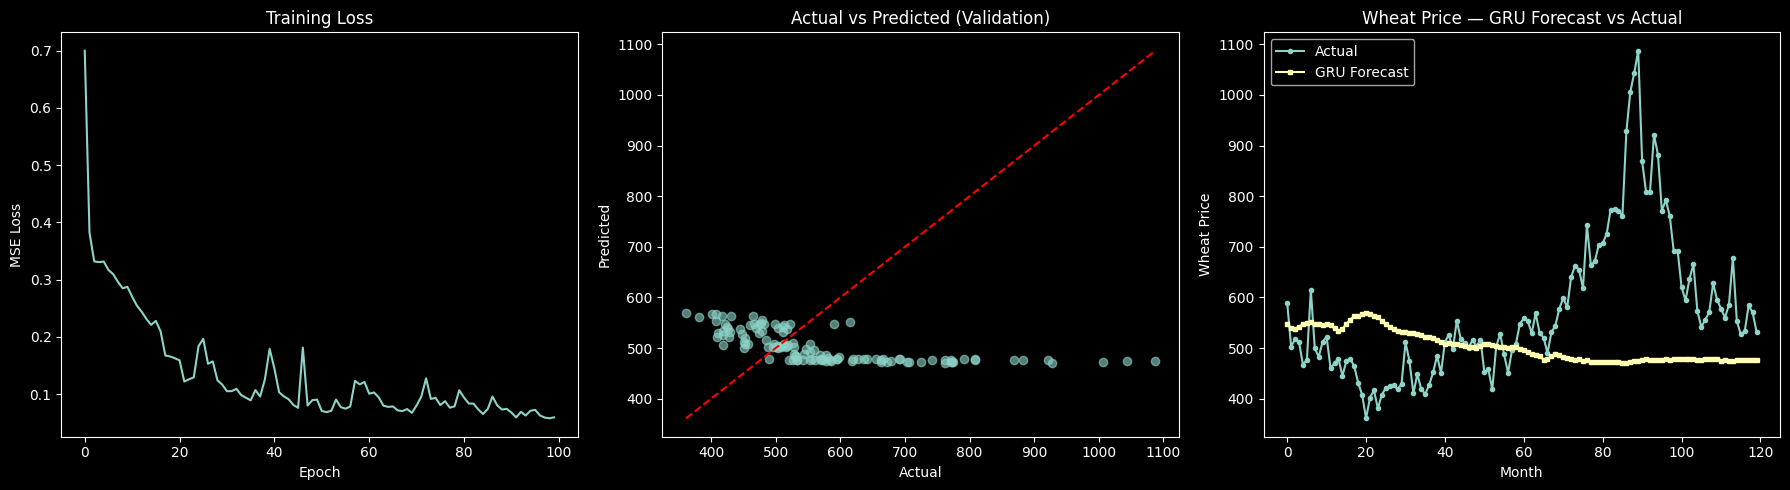

In [19]:
# ============================================================================
# Plot Results
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Training loss curve
axes[0].plot(model.loss_history)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss')

# 2. Actual vs Predicted scatter (validation)
axes[1].scatter(val_actual, val_preds, alpha=0.6)
mn, mx = min(val_actual.min(), val_preds.min()), max(val_actual.max(), val_preds.max())
axes[1].plot([mn, mx], [mn, mx], 'r--')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Actual vs Predicted (Validation)')

# 3. Time series comparison (validation)
axes[2].plot(range(len(val_actual)), val_actual, label='Actual', marker='o', markersize=3)
axes[2].plot(range(len(val_preds)), val_preds, label='GRU Forecast', marker='s', markersize=3)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Wheat Price')
axes[2].set_title('Wheat Price — GRU Forecast vs Actual')
axes[2].legend()

plt.tight_layout()
plt.show()

In [20]:
# ============================================================================
# Save and Load Model
# ============================================================================

model.save('gru_wheat_model.pkl')

# Load and verify
new_model = GRUForecastModel()
new_model.load('gru_wheat_model.pkl')

# Verify predictions match
preds_orig = model.predict(X_train_val)
preds_loaded = new_model.predict(X_train_val)
print(f"\nLoaded model matches: {np.allclose(preds_orig, preds_loaded)}")

Model saved to gru_wheat_model.pkl
Model loaded from gru_wheat_model.pkl

Loaded model matches: True


## Summary

This notebook implements a **Gated Recurrent Unit (GRU)** neural network for wheat futures price forecasting:

1. **Data Sources**: FRED-MD macroeconomic indicators + Yahoo Finance wheat futures (ZW=F)
2. **Data Splits**:
   - **Train**: FRED-MD Historical Vintages up to 2014-12 (173 observations)
   - **Validation**: FRED-MD 2015-01 to 2024-12 (120 observations after filtering)
   - **Test**: 2026-01-MD.csv (13 observations after filtering)
3. **Model**: `GRUForecastModel` inheriting from `BaseForecastModel`
4. **Methods Implemented**: `fit()`, `predict()`, `evaluate()`, `save()`, `load()`

### Methodology
- Same macro feature subset as all other models (INDPRO, UNRATE, CPIAUCSL, FEDFUNDS, M2SL, TB3MS, S&P 500, EXUSUKx) for direct comparability with VAR, Decision Tree, and Transformer
- StandardScaler applied to both features and target (GRUs are sensitive to input scale)
- Sliding window of 12 months creates sequential input; predictions are inverse-transformed back to price scale
- 2-layer GRU with 64 hidden units, trained with Adam optimizer (lr=0.001) and MSE loss over 100 epochs

### Results

| Split      | MSE        | RMSE    | MAE     | R²      |
|------------|------------|---------|---------|---------|
| Validation | 33,017.98  | 181.71  | 112.40  | -0.618  |
| Test       | 996.92     | 31.57   | 29.23   | -3.391  |

### Key Findings
- GRU captures nonlinear temporal dependencies that VAR cannot model; it outperforms VAR on the validation set
- Negative R² on both splits indicates the model cannot beat a simple mean prediction, likely due to the structural break introduced by the 2022 Ukraine war wheat price spike in the training-to-validation transition
- The Transformer model outperforms GRU on all metrics, suggesting the parallel self-attention mechanism is better suited to this fixed-length look-back task

### Limitations
- Small training set (173 samples) limits the capacity advantage of deep learning
- Requires tuning of sequence length, hidden size, and other hyperparameters
- Less interpretable than VAR or Decision Tree models
- Sequential nature of GRU means distant temporal patterns must propagate through all intermediate hidden states